# Hyperparameter Search Techniques

Now we will use search techniques such as `GridSearchCV` and `RandomizedSearchCV` to see how hyperparameter optimisation influences performance and computational cost. We will apply grid search and random search to two different model classes:
- Logistic Regression
- SVM

### Dataset Setup

In [ ]:
# imports
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import randint, loguniform
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

We will use the Bank Marketing dataset from the UCI Repository, which contains information about customers contacted during direct marketing campaigns by a Portuguese bank. The target is whether a contacted client subscribes to a term deposit.

This is a realistic business decision-making scenario where:

- Class imbalance exists (fewer customers subscribe than decline)
- Errors have different costs (contacting uninterested customers wastes budget)
- Consistent performance across classes is essential

In [2]:
# marketing dataset (semicolon separated)
data = pd.read_csv('./datasets/bank-additional/bank-additional-full.csv', sep=';')
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# convert target yes/no to 1/0
data["y"] = data["y"].map({"yes": 1, "no": 0})

In [5]:
data['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

There is a significant imbalance in the classes

One way is to downsample the number of class '0' to bring down the imbalance. Due to the extremely large number of negative class samples, we cannot bring them down to a value comparable with class '1' (around 4-5 thousand). 

However, we can try to downsample the number of negative class samples to somewhere around 15,000 (which is still more than half of the information lost), but this will make the class balance around 3:1, which is much better than earlier.

In [6]:
# first sample from the majority class
downsample = data[data['y'] == 0].sample(n=15000, random_state=1)
# combine back together
df = pd.concat([downsample, data[data['y'] == 1]])

# reshuffle
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19640 entries, 0 to 19639
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             19640 non-null  int64  
 1   job             19640 non-null  object 
 2   marital         19640 non-null  object 
 3   education       19640 non-null  object 
 4   default         19640 non-null  object 
 5   housing         19640 non-null  object 
 6   loan            19640 non-null  object 
 7   contact         19640 non-null  object 
 8   month           19640 non-null  object 
 9   day_of_week     19640 non-null  object 
 10  duration        19640 non-null  int64  
 11  campaign        19640 non-null  int64  
 12  pdays           19640 non-null  int64  
 13  previous        19640 non-null  int64  
 14  poutcome        19640 non-null  object 
 15  emp.var.rate    19640 non-null  float64
 16  cons.price.idx  19640 non-null  float64
 17  cons.conf.idx   19640 non-null 

In [21]:
df['y'].value_counts(normalize=True)

y
0    0.763747
1    0.236253
Name: proportion, dtype: float64

In [8]:
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)
X_train.shape, X_test.shape, y_test.shape, y_train.shape

((15712, 20), (3928, 20), (3928,), (15712,))

### Hyperparameter Search Pipelines

Once again, we will set up a basic transformation and model pipeline. For scoring, we will use F1-score, as we want to identify both potential conversions and avoid false positives. 

The distribution is imbalanced and only a fraction of the marketing leads were converted. To ensure fair class performance, we use macro F1 score:

$$
\text{Macro-F1} = \frac{1}{C} \sum_{c=1}^{C} F1_c
$$

This computes F1 for each class independently and then takes the simple (unweighted) average. Macro-F1 rewards models that do consistently well across all classes.

This dataset contains both numeric and categorical attributes. To ensure numerically stable training and prevent information leakage during tuning, we wrap preprocessing and modelling within a single pipeline:

- One-hot encoding of categorical features
- StandardScaler applied only to numeric columns
- Classifier as the final step

Using a unified pipeline allows the same model selection workflow to apply cleanly to both classical and neural models, while guaranteeing that preprocessing is refit properly within each cross-validation split.

In [9]:
# Identify feature types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Preprocessing pipeline
preprocess = ColumnTransformer([("num", StandardScaler(), num_cols),
                                ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

#### Grid Search

For grid search, we define a grid of all hyperparameter values, which cross validation uses while seaching. 

> `GridSearchCV(estimator, param_grid, cv, scoring, n_jobs)` tests combinations of hyperparameters under cross-validation to find the best model. After `.fit()`, use `best_params_` and `best_estimator_` to retrieve the optimal configuration.


Let's start with small grids first.


##### Model 1: Logistic Regression

In [ ]:
logreg_pipe = Pipeline([("prep", preprocess),
                        ("clf", LogisticRegression(max_iter=500))])

logreg_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0, 100.0]}  # inverse regularisation strength

logreg_gs = GridSearchCV(logreg_pipe, logreg_grid,
                         scoring='f1_macro', cv=3,
                         n_jobs=-1, return_train_score=True)

logreg_gs.fit(X_train, y_train)

best_logreg = logreg_gs.best_estimator_
logreg_gs.best_params_

{'clf__C': 100.0}

A point to note here is that inside a Pipeline, hyperparameters must be prefixed with the step name. Here the step name is *"clf"*.

In [30]:
# let's check accuracy of the model
accuracy_score(best_logreg.predict(X_test), y_test)

0.870162932790224

In [31]:
recall_score(best_logreg.predict(X_test), y_test), precision_score(best_logreg.predict(X_test), y_test) # recall and precision

(0.7605985037406484, 0.6573275862068966)

##### Model 2: SVM

Here, let's pass two types of kernels to grid search. Note that we do not need to provide values for `gamma` in case of linear SVC. In this case, we can give two different parameter grids, as a list.

In [32]:
svm_pipe = Pipeline([("prep", preprocess),
                     ("clf", SVC(random_state=1))]) 

svm_grid = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10, 100]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": [0.001, 0.01, 0.1, 1]
    }
]

svm_gs = GridSearchCV(svm_pipe, svm_grid, 
                      scoring='f1_macro', cv=3, n_jobs=-1,    # cv: 3-Fold CV splits
                      return_train_score=True, verbose = 3)

svm_gs.fit(X_train, y_train)
best_svm = svm_gs.best_estimator_
svm_gs.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


{'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}

In [33]:
# let's check accuracy of the SVM
accuracy_score(best_svm.predict(X_test), y_test)

0.8778004073319755

In [34]:
recall_score(best_svm.predict(X_test), y_test), precision_score(best_svm.predict(X_test), y_test) # recall and precision

(0.7440087145969498, 0.7359913793103449)

##### Learning Curves

We should pause here and to understand how the current tuned models behave as the amount of training data increases, over the course of the training cycle. Hyperparameters dont only influence the final cross-validated score, they also shape the model’s learning dynamics.

Learning curves allow us to examine two key aspects

1. Underfitting and overfitting
   - Large gap between training and validation performance shows potential overfitting while low scores for both means model may be underpowered or lacking complexity

2. Data dependence
   - If validation performance continues rising as we add more data, further data collection may be beneficial
   - If performance plateaus early, tuning might be more impactful than adding data (early stopping)

By comparing Logistic Regression and SVM side-by-side, we can observe whether their current hyperparameter configurations support good generalisation behaviour

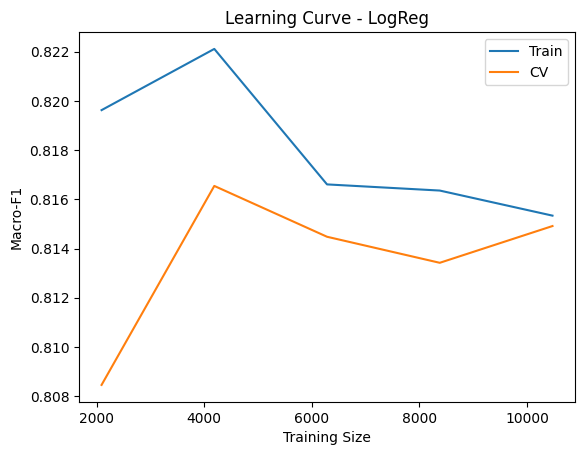

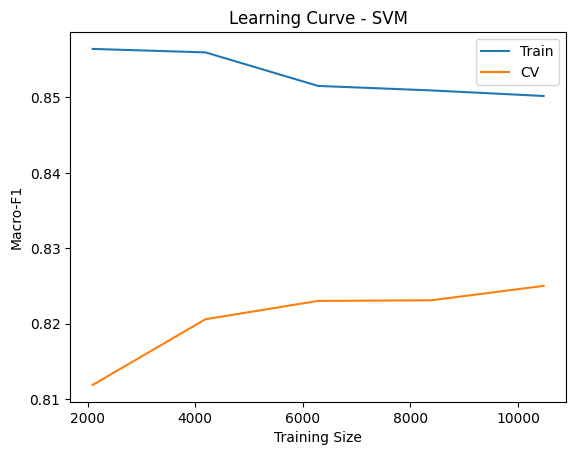

In [35]:
def plot_learning_curve(model, title):
    sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, 
                                                     cv=3, scoring='f1_macro', 
                                                     train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1 )
    plt.figure()
    plt.plot(sizes, train_scores.mean(axis=1), label="Train")
    plt.plot(sizes, val_scores.mean(axis=1), label="CV")
    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.show()

plot_learning_curve(best_logreg, "Learning Curve - LogReg")
plot_learning_curve(best_svm, "Learning Curve - SVM")

**Logistic Regression**

Both the training and validation curves flatten early and stay close together. This suggests low variance and limited capacity (increasing data does not significantly improve generalisation)

The slight decrease in training score as sample size grows is expected. With more instances to fit, the model becomes less able to perfectly match all points, so training performance declines while the model stays simple and stable.

Overall, logistic regression is likely underfitting the underlying structure. It has learned most of what is possible for its level of complexity. 

<br>

**SVM (RBF Kernel)**

Here, the gap between training and validation is larger, especially at small sample sizes. This shows higher variance in small-data regimes.

Validation performance improves as training size increases, matching intuition that SVM benefits more from additional examples. The training curve declines gradually as the decision boundary needs to generalise over a broader set of points.

This behaviour shows that the SVM can still learn more as data increases


Thus, the SVM demonstrates stronger potential to benefit from tuning and data. So, let's try random search on SVM to try and find a bit more optimised set of hyperparameters.


> *The CV curves can be slightly noisy (common with small k). Small oscillations may occur due to 3-fold variability and not model instability.*

#### Random Search for Fine Tuning SVM

> `RandomizedSearchCV(estimator, param_distributions, n_iter, cv, scoring, n_jobs)` evaluates a specified number of randomly sampled hyperparameter configurations drawn from defined distributions under cross-validation. It aims to efficiently approximate the best model without exhaustively testing all possibilities. 
> 
> After `.fit()`, use `best_params_` and `best_estimator_` to obtain the optimal result identified.


Grid Search helped us locate a good region in the (C, gamma) space. We now refine our search around those best values using Random Search. The aim is to find stronger hyperparameters without expanding the search too widely and increasing runtime.

We can
- search C values slightly above and below 10
- search gamma values slightly above and below 0.01 on a log scale

In [40]:
# focused search around the best grid params
svm_local_params = {"clf__C": loguniform(5, 50),           # search around C ≈ 10
                    "clf__gamma": loguniform(1e-3, 5e-2),  # search around gamma ≈ 0.01
}

svm_local_rs = RandomizedSearchCV(svm_pipe, svm_local_params, 
                                  n_iter=20,              # slightly more exploration because the space is small
                                  scoring='f1_macro', cv=3,
                                  n_jobs=-1, random_state=1)

svm_local_rs.fit(X_train, y_train)

best_svm_rs = svm_local_rs.best_estimator_

svm_local_rs.best_params_

{'clf__C': np.float64(5.215047658906665),
 'clf__gamma': np.float64(0.018813633956610076)}

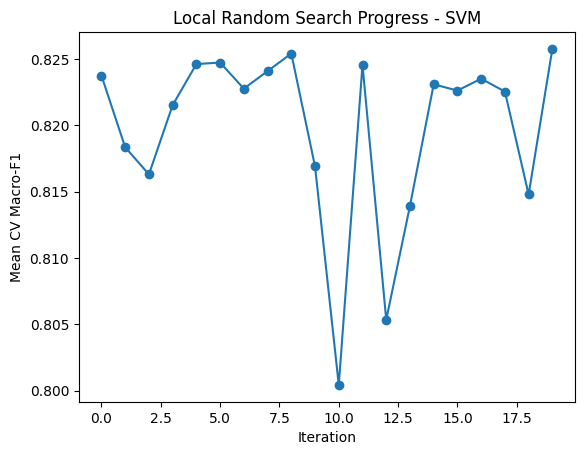

In [41]:
plt.plot(svm_local_rs.cv_results_["mean_test_score"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("Mean CV Macro-F1")
plt.title("Local Random Search Progress - SVM")
plt.show()

In [42]:
# metrics
accuracy_score(best_svm_rs.predict(X_test), y_test), recall_score(best_svm_rs.predict(X_test), y_test), precision_score(best_svm_rs.predict(X_test), y_test) 

(0.8806008146639511, 0.7438894792773645, 0.7543103448275862)

The fine-tuning of hyperparameters did not reveal any particularly major improvements. In other words, the remaining performance gap is more likely due to the limits of the data rather than hyperparameter sensitivity in a small range.


However, random search took much lesser time than grid search to perform cross-validation, and may prove a better strategy for fine-tuning rather than exhaustive searching. 

Let's take a look at the learning curve as well

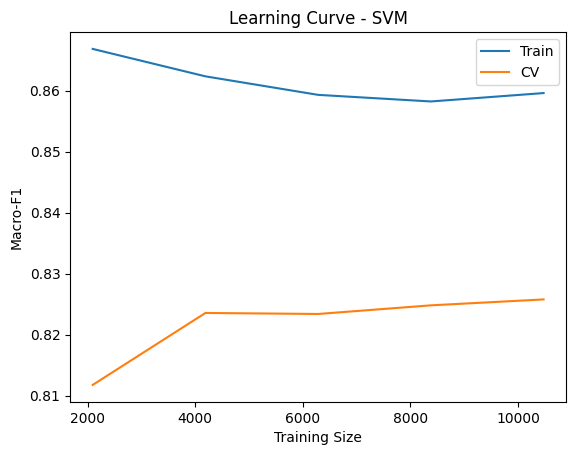

In [43]:
plot_learning_curve(best_svm_rs, "Learning Curve - SVM")

The updated learning curve for SVM shows a clearer separation between the training and validation lines. The training score gradually declines as the model is required to generalise, and the validation score continues to rise slowly with increasing training size.

This pattern suggests that the SVM still benefits from additional data and has not yet fully reached its generalisation capacity. The model is not strongly overfitting: the gap between train and validation performance is moderate but stable.

### Comparison and Model Cards


A **model card** is a concise report that summarises a model’s behaviour, strengths, limitations, and appropriate usage scenarios. It supports responsible deployment by ensuring that the chosen model is not only accurate, but also aligned with operational and fairness requirements.

Model cards help stakeholders answer:
- When should this model be used?
- Where might it fail or behave unpredictably?
- What risks should decision makers be aware of?

This allows us to justify our selection in terms of both performance and practicality, rather than relying solely on a single evaluation metric.


In [47]:
candidates = {"LogReg (Grid)": best_logreg, "SVM (Grid)": best_svm, "SVM (Random)": best_svm_rs}

results = {}
for name, model in candidates.items():
    preds = model.predict(X_test)
    report = classification_report(y_test, preds, output_dict=True)
    results[name] = report["macro avg"]["f1-score"]

results

# report

{'LogReg (Grid)': 0.8109752990664258,
 'SVM (Grid)': 0.8300557215042462,
 'SVM (Random)': 0.8353636374441753}

##### Logistic Regression
**Core idea:** Linear decision boundary separating classes

**Strengths**
- Very fast to train and predict
- Highly interpretable weights
- Stable behaviour with limited training data

**Weaknesses**
- Underfits non-linear relationships
- Performance saturates early

**Best use case:** When transparency and deployment speed are priorities, and slight accuracy trade-offs are acceptable


##### SVM 
**Core idea:** Flexible nonlinear separator using an RBF kernel

**Strengths**
- Better captures complex boundaries in the data
- Benefits from more training data
- Higher Macro-F1 in both CV and test evaluation

**Weaknesses**
- More computationally expensive at inference time
- Requires careful tuning

**Best use case:** When predictive performance matters most and inference load is manageable



To select the final model, final decision criteria applied:
1. Macro-F1 as the primary performance measure  
2. If scores close → prefer simpler + faster inference  
3. Consider learning curve diagnostics (under/overfitting behaviour)


We can select SVM as the choice for this simple demonstration. 

In real world problems, you will face much more complex data patterns, model performances, and model choices. But the core ideas of model selection will remain the same:
- Business and domain understanding
- Interpretability needs
- Data characterstics
- Cost considerations and scalability
- Justifiability of the model